In [26]:
import sys
import numpy as np
sys.path.append("../src/")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
from generators.toy_problem_to_json import toy_problem_to_json # type: ignore[reportMissingImports]
from relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx # type: ignore[reportMissingImports]
from relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate # type: ignore[reportMissingImports]
from relaxers.quadratic_model_remove_quad import quadratic_model_remove_quad # type: ignore[reportMissingImports]
from testers.condition_number_lin_program import ( # type: ignore[reportMissingImports]
    condition_number,
    condition_number_no_bounds,
    condition_number_nes_basic
)
from relaxers.standard_form import standard_form # type: ignore[reportMissingImports]

np.set_printoptions(linewidth=np.inf)

In [28]:
# Number of copies of the network in the toy system
N=20

# Whether the production and flow variables have upper bounds
=True
F_UPPER_BOUNDS=True

# Whether the demand constraint is an equality or inequality
DEMAND_INEQUALITY=False

# Capacity / demand parameters
GAMMA=1.0
# GAMMA=3.0
LAMBD=1.0
EPS=0.1
DELTA=0.1

# Lower bounds and upper bound on pressure
LX=LP=LF=0.0
UP=5.0

# The number of linear constraints to use per quadratic constraint
LIN_CONSTRAINTS = 5

# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = False

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to divide by lambda in an inner approximation
REMOVE_DIVISION = False

There are 259 variables, 100 equality constraints, and 0 non-bound inequality constraints
Removed 100 unused variables
A =
[[ 1.  0.  0. ...  0.  0.  0.]
 [ 0.  1.  0. ...  0.  0.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -1.  0.  0.]
 [ 0.  0.  0. ...  0. -1.  1.]
 [ 0.  0.  0. ... -1. -1.  0.]]
cond(A) = 3.912640178714982
A' =
[]
[[ 3.  0.  0. ...  0.  0.  0.]
 [ 0.  3.  0. ...  0.  0.  0.]
 [ 0.  0.  3. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  4.  1.  0.]
 [ 0.  0.  0. ...  1.  4. -1.]
 [ 0.  0.  0. ...  0. -1.  4.]]
Sparsity of NES: 0.9721925556742217
AxesImage(shape=(159, 159))


np.float64(4.762269999610536)

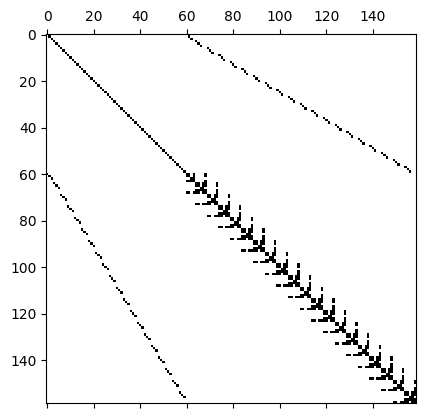

In [29]:
toy_problem_to_json(N, , F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
quadratic_model_remove_quad()
condition_number_nes_basic(bounds=2, verbose=True)

There are 358 variables, 100 equality constraints, and 594 non-bound inequality constraints
Removed 0 unused variables
A =
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
cond(A) = 3.9126401787149834
A' =
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
cond(A') = inf
[[3. 0. 0. ... 0. 0. 0.]
 [0. 3. 0. ... 0. 0. 0.]
 [0. 0. 3. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 8. 0. 0.]
 [0. 0. 0. ... 0. 8. 0.]
 [0. 0. 0. ... 0. 0. 8.]]
Sparsity of NES: 0.9867825598451984
AxesImage(shape=(358, 358))


np.float64(22.487343559473395)

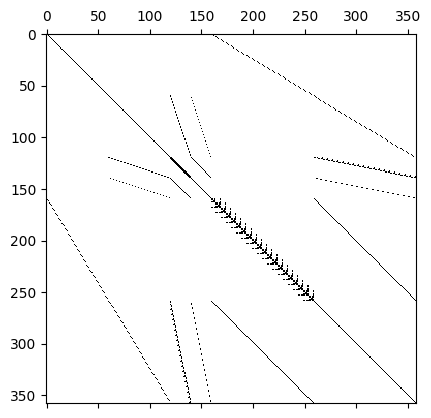

In [30]:
toy_problem_to_json(N, , F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
# quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
condition_number_nes_basic(bounds=2, verbose=True)

There are 29 variables, 13 equality constraints, and 88 non-bound inequality constraints
Removed 0 unused variables
A =
[[ 0.          0.          1.         -1.          0.          0.          1.          0.          0.         -1.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.         -1.          0.          1.          1.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.         -1.         -1.          0.          0.          0.          1.          0.          0.          0.          0.     

np.float64(4487.514930440092)

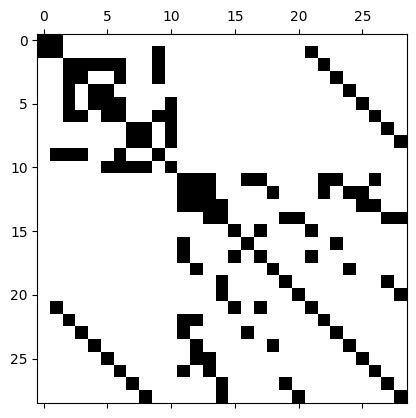

In [41]:
quadratic_model_lin_approx(10, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                f_name="model11_quad_reform.json")
# quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
#                                 SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
#                                 f_name="model11_quad.json")
# quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, True, f_name="model11_quad_reform.json")
# quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, True, f_name="model11_quad.json")
condition_number_nes_basic(bounds=2, verbose=True)

There are 117 variables, 101 equality constraints, and 0 non-bound inequality constraints
Removed 0 unused variables
A =
[[ 0.  0.  1. ...  0.  0.  0.]
 [ 0.  0. -1. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ...  0.  1.  0.]
 [ 0.  0.  0. ...  0.  0.  1.]]
cond(A) = 18857.13882604042
A' =
[]
[[ 3.00000000e+00 -1.00000000e+00  0.00000000e+00 ...  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.00000000e+00  9.01035557e+03  0.00000000e+00 ...  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  9.01035557e+03 ...  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  3.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00  3.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00  0.00000000e+00  3.00000000e+00]]
Sparsity of NES: 0.95711885

np.float64(4510.588098610856)

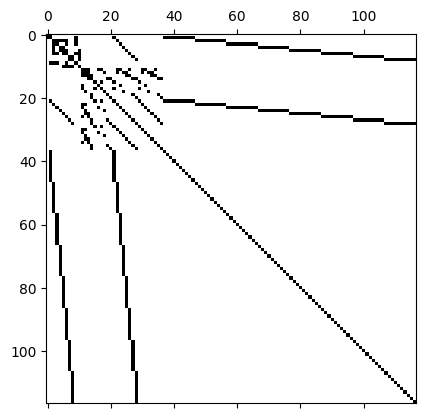

In [40]:
quadratic_model_lin_approx(10, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                f_name="model11_quad_reform.json")
standard_form()
condition_number_nes_basic(bounds=2, verbose=True)